## Cuáles son las habilidades más demandadas para los 3 roles de datos más populares?

In [ ]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast 

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
df_US = df[df['job_country'] == 'United States']

In [ ]:
df_skills = df_US.explode('job_skills')

In [ ]:
df_skills['job_skills'] = df_skills['job_skills'].str.capitalize()

df_skills

In [ ]:
df_skills_count = df_skills.groupby(['job_skills','job_title_short']).size()

df_skills_count 

In [ ]:
df_skills_count = df_skills_count.reset_index(name='skill_count')


In [ ]:
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)

df_skills_count

In [ ]:
job_titles = df_skills_count['job_title_short'].unique().tolist()

job_titles = sorted(job_titles[:3])

job_titles

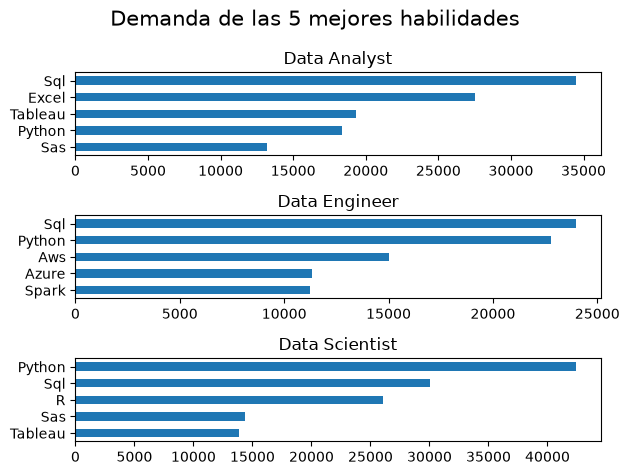

In [27]:
fig, ax = plt.subplots(len(job_titles), 1,)

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title, legend=False)
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')

fig.suptitle('Demanda de las 5 mejores habilidades', fontsize=15)
plt.tight_layout()
plt.show()

In [30]:
df_job_title_count =df_US['job_title_short'].value_counts().reset_index(name='jobs_total')

In [ ]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how='left', on='job_title_short')

df_skills_perc['skill_perc'] = 100 * df_skills_perc['skill_count'] / df_skills_perc['jobs_total']

df_skills_perc

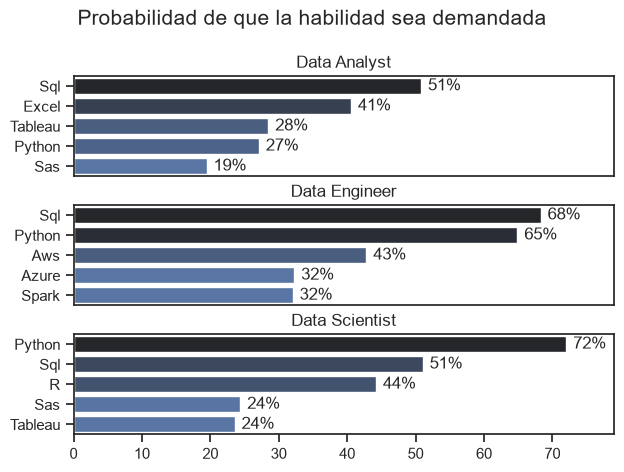

In [88]:
fig, ax = plt.subplots(len(job_titles), 1,)

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_perc', y='job_skills', ax=ax[i], hue='skill_count', palette='dark:b_r', legend=False)
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].set_xlim(0,79)

    for n, v in enumerate(df_plot['skill_perc']):
        ax[i].text(v + 1, n, f'{v:.0f}%', va='center')

    if i != len(job_titles) - 1:
        ax[i].set_xticks([])

fig.suptitle('Probabilidad de que la habilidad sea demandada', fontsize=15)
plt.tight_layout(h_pad=0.5)
plt.show()